In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("ML Environment Ready!")

ML Environment Ready!


In [7]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [9]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

print(df['Order Date'].head())

0   2016-11-08
1   2016-11-08
2   2016-06-12
3   2015-10-11
4   2015-10-11
Name: Order Date, dtype: datetime64[ns]


In [11]:
df = df.sort_values('Order Date')

In [12]:
sales_data = df.groupby('Order Date')['Sales'].sum().reset_index()

print(sales_data.head())

  Order Date     Sales
0 2014-01-03    16.448
1 2014-01-04   288.060
2 2014-01-05    19.536
3 2014-01-06  4407.100
4 2014-01-07    87.158


In [13]:
sales_data['Year'] = sales_data['Order Date'].dt.year
sales_data['Month'] = sales_data['Order Date'].dt.month
sales_data['Day'] = sales_data['Order Date'].dt.day
sales_data['Weekday'] = sales_data['Order Date'].dt.weekday

print(sales_data.head())

  Order Date     Sales  Year  Month  Day  Weekday
0 2014-01-03    16.448  2014      1    3        4
1 2014-01-04   288.060  2014      1    4        5
2 2014-01-05    19.536  2014      1    5        6
3 2014-01-06  4407.100  2014      1    6        0
4 2014-01-07    87.158  2014      1    7        1


In [14]:
X = sales_data[['Year', 'Month', 'Day', 'Weekday']]

y = sales_data['Sales']

In [15]:
model = LinearRegression()

model.fit(X, y)

predictions = model.predict(X)

In [16]:
mae = mean_absolute_error(y, predictions)

rmse = np.sqrt(mean_squared_error(y, predictions))

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 1463.252729914467
Root Mean Squared Error: 2218.766370285959


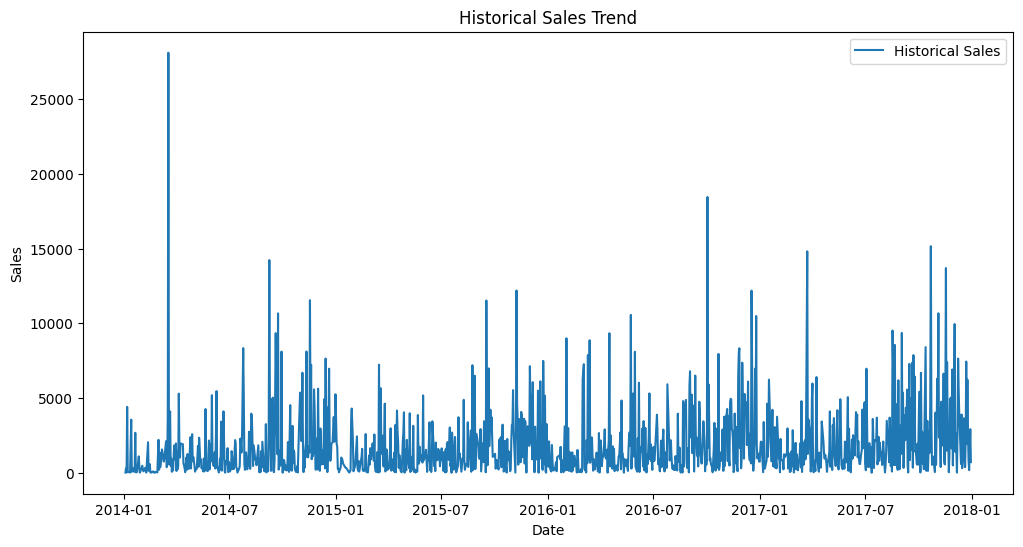

In [17]:
plt.figure(figsize=(12,6))

plt.plot(
    sales_data['Order Date'],
    y,
    label='Historical Sales'
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Historical Sales Trend")

plt.legend()

plt.show()

In [18]:
future_dates = pd.date_range(
    start='2018-01-01',
    periods=30
)

future_df = pd.DataFrame({
    'Order Date': future_dates
})

In [19]:
future_df['Year'] = future_df['Order Date'].dt.year
future_df['Month'] = future_df['Order Date'].dt.month
future_df['Day'] = future_df['Order Date'].dt.day
future_df['Weekday'] = future_df['Order Date'].dt.weekday

In [20]:
future_predictions = model.predict(
    future_df[['Year', 'Month', 'Day', 'Weekday']]
)

future_df['Predicted Sales'] = future_predictions

print(future_df.head())

  Order Date  Year  Month  Day  Weekday  Predicted Sales
0 2018-01-01  2018      1    1        0      1534.598516
1 2018-01-02  2018      1    2        1      1545.237894
2 2018-01-03  2018      1    3        2      1555.877273
3 2018-01-04  2018      1    4        3      1566.516652
4 2018-01-05  2018      1    5        4      1577.156031


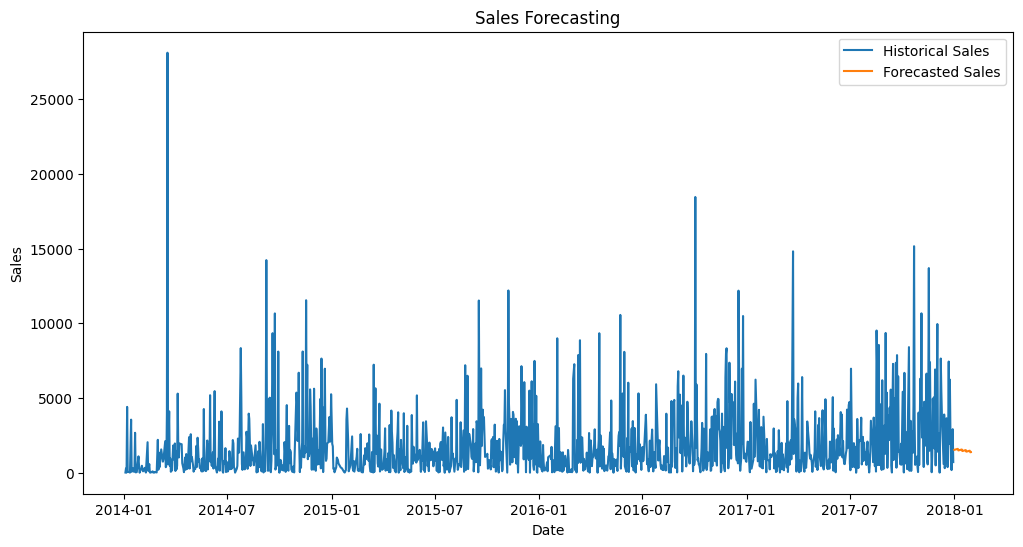

In [21]:
plt.figure(figsize=(12,6))

plt.plot(
    sales_data['Order Date'],
    y,
    label='Historical Sales'
)

plt.plot(
    future_df['Order Date'],
    future_df['Predicted Sales'],
    label='Forecasted Sales'
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Forecasting")

plt.legend()

plt.show()

In [23]:
print("Business Insights")
print("------------------")

print("1. Forecasting helps estimate future sales.")
print("2. Businesses can plan inventory better.")
print("3. Seasonal sales trends support staffing decisions.")
print("4. Forecasting reduces overstocking and losses.")

Business Insights
------------------
1. Forecasting helps estimate future sales.
2. Businesses can plan inventory better.
3. Seasonal sales trends support staffing decisions.
4. Forecasting reduces overstocking and losses.
